# Neurodegenerative Disease Prediction using Machine Learning

**Dataset:** AIBL (Australian Imaging, Biomarkers & Lifestyle) Study of Ageing  
**Objective:** Classify patients into Normal Cognition, Mild Cognitive Impairment (MCI), or Alzheimer's Disease (AD) using clinical biomarkers, cognitive assessments, and genetic risk factors.

---

## Background

Neurodegenerative diseases affect millions worldwide. Early and accurate diagnosis is critical for intervention:

| Condition | Description |
|-----------|-------------|
| **Normal Cognition** | Age-normal cognitive function |
| **MCI** | Mild Cognitive Impairment — transitional state between normal aging and AD |
| **Alzheimer's Disease** | Progressive neurodegeneration with memory loss and cognitive decline |

**Key Biomarkers Used:**
- **APOE Genotype** — Strongest genetic risk factor for late-onset AD (APOE ε4 allele)
- **CDR Global** — Clinical Dementia Rating: 0=Normal, 0.5=Questionable, 1=Mild, 2=Moderate
- **LIMMTOTAL / LDELTOTAL** — Immediate and Delayed Recall scores (ADAS-Cog battery)
- **Hematology & Blood Chemistry** — Systemic biomarkers associated with neurodegeneration

---

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, ConfusionMatrixDisplay
)

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries imported successfully.')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__}')

All libraries imported successfully.
NumPy: 2.4.3 | Pandas: 3.0.1


## 2. Data Loading & Initial Exploration

In [2]:
df = pd.read_csv('Neural_Network_AlzheimersDisease/Data/aibl_merged_clean.csv')

print(f'Dataset shape: {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
df.head()

Dataset shape: (862, 36)
Memory usage: 482.2 KB


,RID,SITEID,VISCODE,PTGENDER,PTDOB,SITEID_r,VISCODE_r,APTESTDT,APGEN1,APGEN2,...,HMT3,HMT7,HMT13,HMT40,HMT100,HMT102,RCT6,RCT11,RCT20,RCT392
0,2,1,bl,1,/1941,1,bl,09/16/2011,3,3,...,4.39,5.5,220.0,14.4,32.8,34.3,37.844,90.080,173.993,0.916
1,3,1,bl,2,/1939,1,bl,10/19/2007,4,3,...,3.87,5.2,254.0,12.6,32.5,34.2,18.021,129.715,251.322,0.792
2,4,1,bl,2,/1922,1,bl,02/02/2007,3,3,...,4.13,6.8,327.0,13.1,31.7,34.2,52.261,86.477,216.524,1.018
3,5,1,bl,1,/1933,1,bl,02/05/2007,3,3,...,5.64,5.7,140.0,16.5,29.3,34.0,33.038,108.096,162.393,1.131
4,10,1,bl,1,/1925,1,bl,02/26/2007,4,4,...,4.29,4.8,164.0,15.0,34.9,35.1,33.639,126.112,158.526,1.131


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Data Types ===
RID             int64
SITEID          int64
VISCODE           str
PTGENDER        int64
PTDOB             str
SITEID_r        int64
VISCODE_r         str
APTESTDT          str
APGEN1          int64
APGEN2          int64
APRECEIVE       int64
APAMBTEMP       int64
DXCURREN        int64
DXNORM          int64
DXNODEP         int64
DXMCI           int64
DXAD            int64
DXPARK          int64
DXOTHDEM        int64
EXAMDATE          str
CDGLOBAL      float64
EXAMDATE_r        str
LIMMTOTAL       int64
LDELTOTAL       int64
AXT117        float64
BAT126        float64
HMT3          float64
HMT7          float64
HMT13         float64
HMT40         float64
HMT100        float64
HMT102        float64
RCT6          float64
RCT11         float64
RCT20         float64
RCT392        float64
dtype: object

=== Missing Values ===
RID           0
SITEID        0
VISCODE       0
PTGENDER      0
PTDOB         0
SITEID_r      0
VISCODE_r     0
APTESTDT      0
APGEN1        0
APGEN2 

In [4]:
# Map DXCURREN to diagnosis labels
# 1=Normal, 2=MCI, 3=AD, 7=Other dementia, -4=Not applicable
dx_map = {1: 'Normal', 2: 'MCI', 3: 'AD', 7: 'Other', -4: 'Unknown'}
df['Diagnosis'] = df['DXCURREN'].map(dx_map)

print('=== Diagnosis Distribution ===')
counts = df['Diagnosis'].value_counts()
print(counts)
print(f'\nTotal samples: {len(df)}')

=== Diagnosis Distribution ===
Diagnosis
Normal     609
MCI        144
AD         105
Other        3
Unknown      1
Name: count, dtype: int64

Total samples: 862


In [5]:
# APOE genotype description
# Common APOE alleles: 2, 3, 4
# APOE4 homozygous (4/4) has ~12x risk for AD
print('APGEN1 (APOE allele 1):', df['APGEN1'].value_counts().to_dict())
print('APGEN2 (APOE allele 2):', df['APGEN2'].value_counts().to_dict())

df['APOE4_count'] = ((df['APGEN1'] == 4).astype(int) + (df['APGEN2'] == 4).astype(int))
print('\nAPOE4 allele count distribution:')
print(df['APOE4_count'].value_counts())

APGEN1 (APOE allele 1): {3: 531, 4: 302, -4: 27, 2: 2}
APGEN2 (APOE allele 2): {3: 668, 2: 116, 4: 51, -4: 27}

APOE4 allele count distribution:
APOE4_count
0    560
1    251
2     51
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

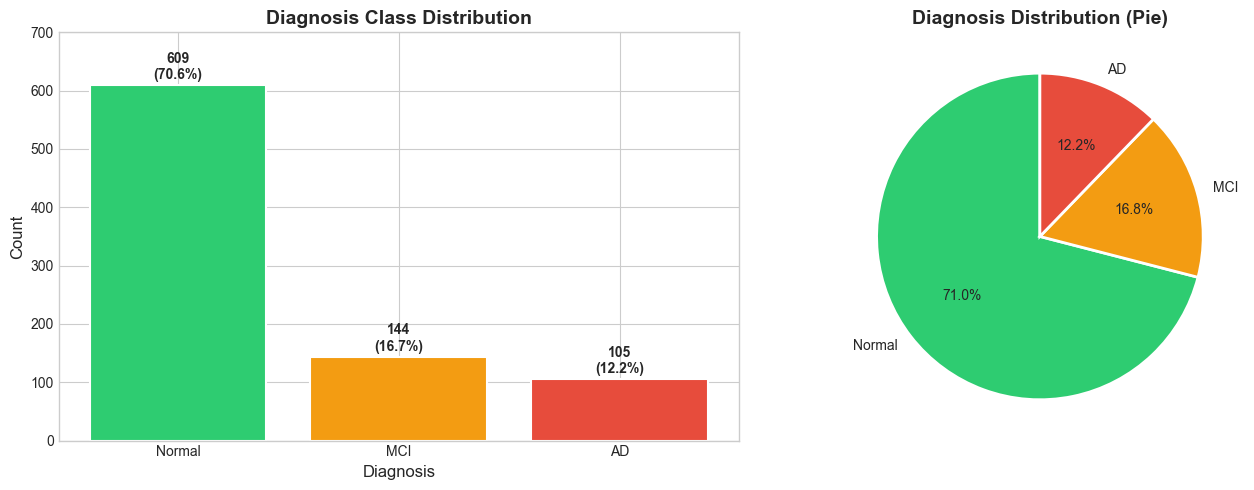

Fig saved: class_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution bar chart
palette = {'Normal': '#2ECC71', 'MCI': '#F39C12', 'AD': '#E74C3C', 'Other': '#9B59B6', 'Unknown': '#95A5A6'}
counts_clean = df[df['Diagnosis'].isin(['Normal','MCI','AD'])]['Diagnosis'].value_counts()

bars = axes[0].bar(counts_clean.index, counts_clean.values,
                   color=[palette[d] for d in counts_clean.index], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts_clean.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Diagnosis Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_ylim(0, 700)

# Pie chart
axes[1].pie(counts_clean.values, labels=counts_clean.index,
            colors=[palette[d] for d in counts_clean.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Diagnosis Distribution (Pie)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig saved: class_distribution.png')

Working dataset (3-class): (858, 38)


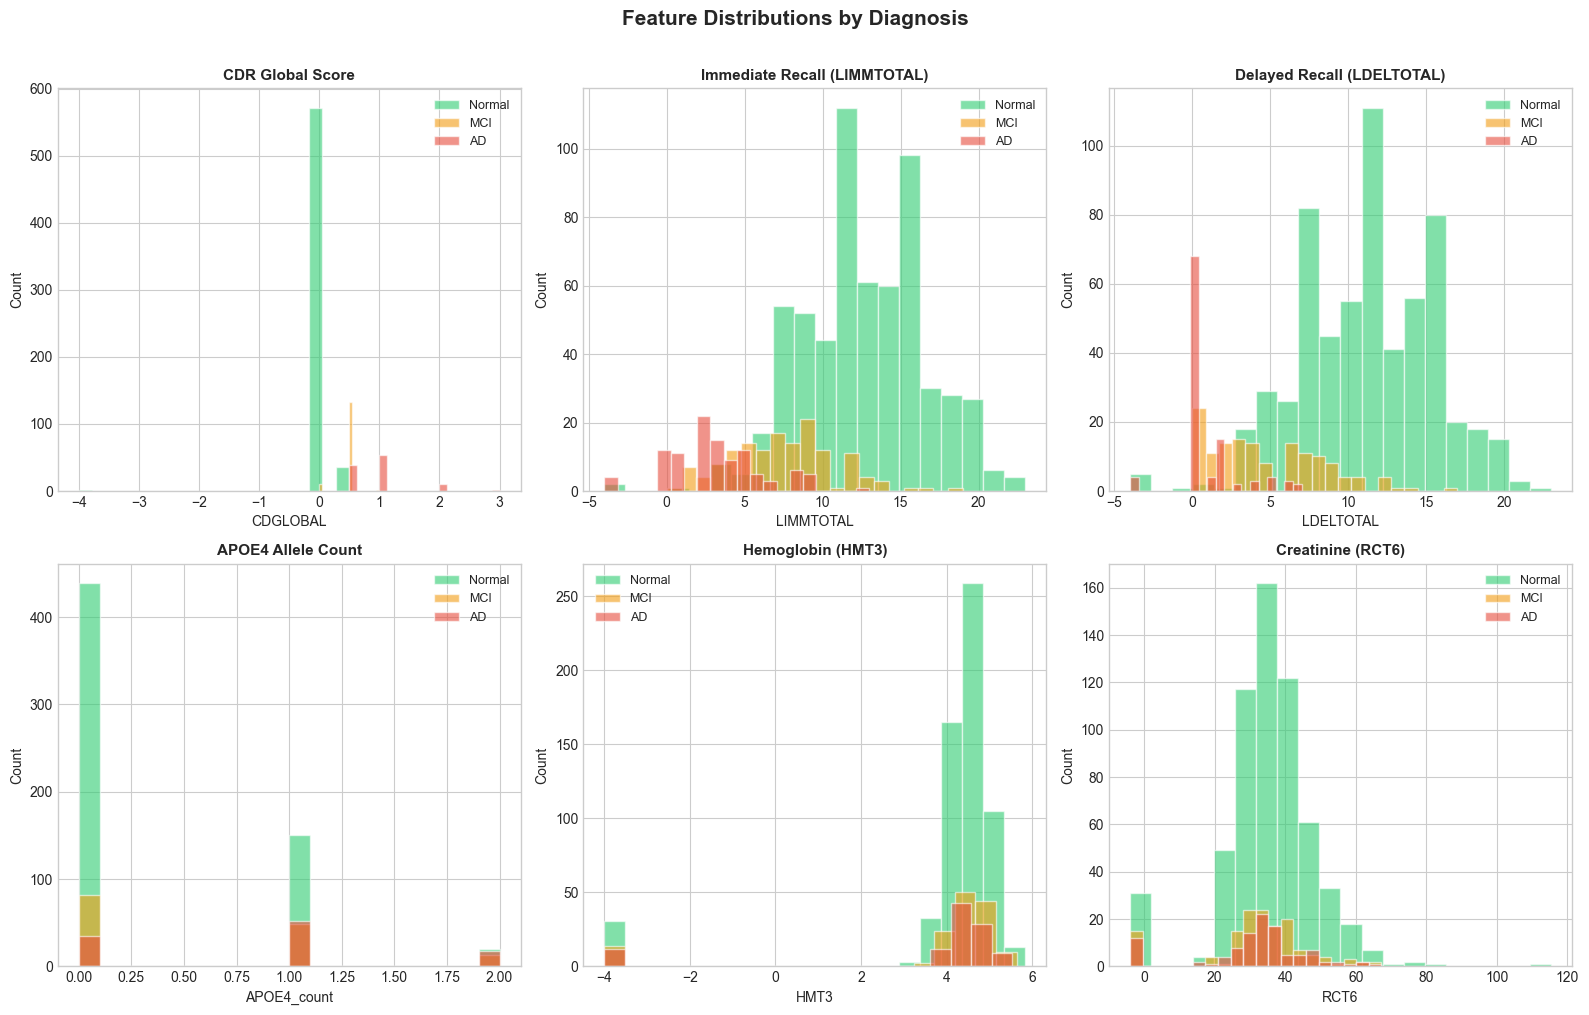

Fig saved: feature_distributions.png


In [7]:
# Filter to 3-class problem (Normal, MCI, AD)
df3 = df[df['Diagnosis'].isin(['Normal', 'MCI', 'AD'])].copy()
print(f'Working dataset (3-class): {df3.shape}')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_features = [
    ('CDGLOBAL', 'CDR Global Score'),
    ('LIMMTOTAL', 'Immediate Recall (LIMMTOTAL)'),
    ('LDELTOTAL', 'Delayed Recall (LDELTOTAL)'),
    ('APOE4_count', 'APOE4 Allele Count'),
    ('HMT3', 'Hemoglobin (HMT3)'),
    ('RCT6', 'Creatinine (RCT6)'),
]

for ax, (feat, title) in zip(axes, plot_features):
    for dx in ['Normal', 'MCI', 'AD']:
        data = df3[df3['Diagnosis'] == dx][feat].dropna()
        ax.hist(data, bins=20, alpha=0.6, label=dx, color=palette[dx], edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions by Diagnosis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig saved: feature_distributions.png')

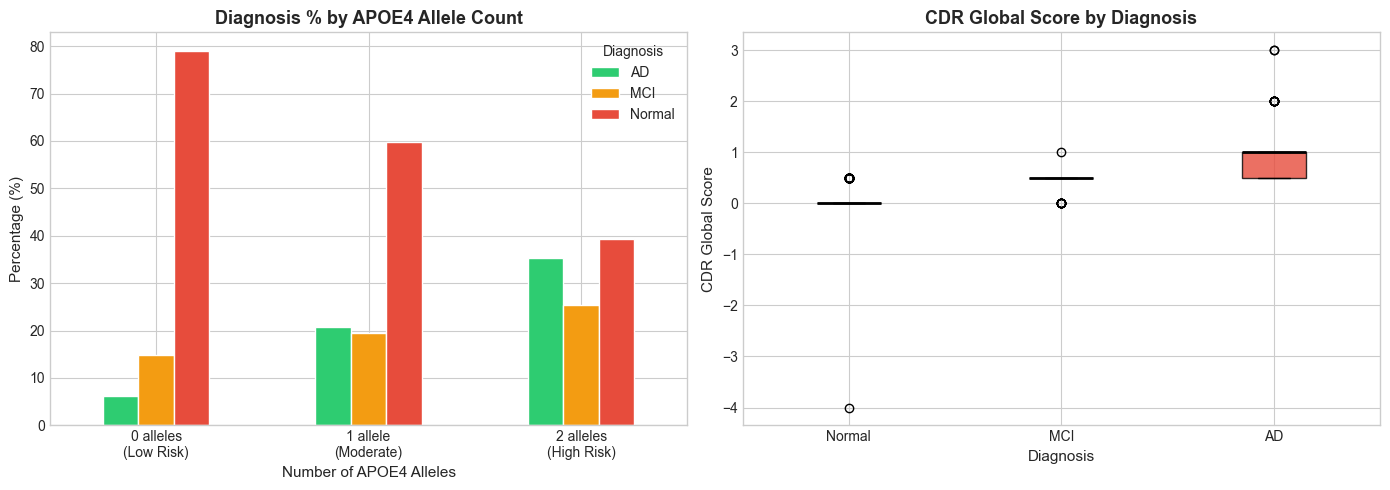

In [8]:
# APOE4 risk stratification
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

apoe_dx = df3.groupby(['APOE4_count', 'Diagnosis']).size().unstack(fill_value=0)
apoe_pct = apoe_dx.div(apoe_dx.sum(axis=1), axis=0) * 100

apoe_pct.plot(kind='bar', ax=axes[0],
              color=[palette['Normal'], palette['MCI'], palette['AD']],
              edgecolor='white', linewidth=1)
axes[0].set_title('Diagnosis % by APOE4 Allele Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of APOE4 Alleles', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].set_xticklabels(['0 alleles\n(Low Risk)', '1 allele\n(Moderate)', '2 alleles\n(High Risk)'], rotation=0)
axes[0].legend(title='Diagnosis')

# CDR score by diagnosis (boxplot)
cdr_data = [df3[df3['Diagnosis'] == dx]['CDGLOBAL'].values for dx in ['Normal', 'MCI', 'AD']]
bp = axes[1].boxplot(cdr_data, labels=['Normal', 'MCI', 'AD'], patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, dx in zip(bp['boxes'], ['Normal', 'MCI', 'AD']):
    patch.set_facecolor(palette[dx])
    patch.set_alpha(0.8)
axes[1].set_title('CDR Global Score by Diagnosis', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Diagnosis', fontsize=11)
axes[1].set_ylabel('CDR Global Score', fontsize=11)

plt.tight_layout()
plt.savefig('apoe_cdr_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

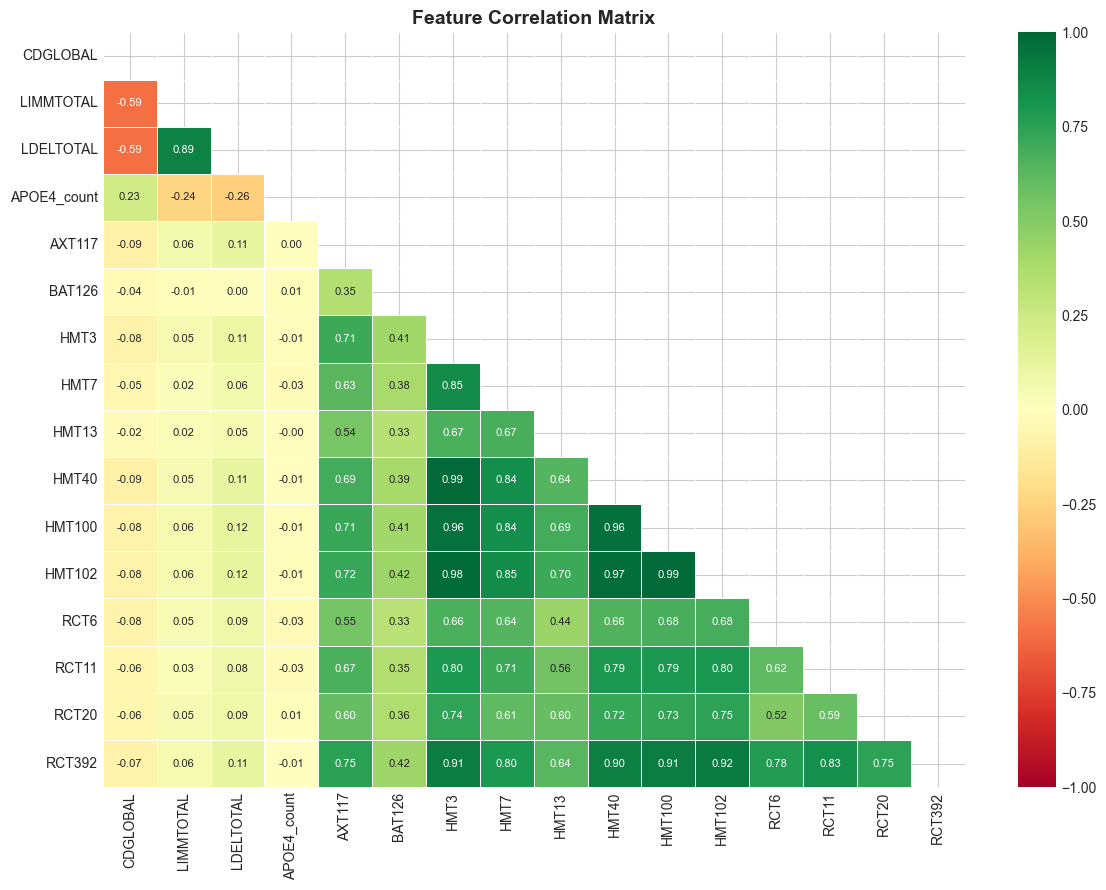

In [9]:
# Correlation heatmap for numerical features
numeric_features = ['CDGLOBAL', 'LIMMTOTAL', 'LDELTOTAL', 'APOE4_count',
                    'AXT117', 'BAT126', 'HMT3', 'HMT7', 'HMT13', 'HMT40',
                    'HMT100', 'HMT102', 'RCT6', 'RCT11', 'RCT20', 'RCT392']

fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df3[numeric_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8},
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering & Preprocessing

In [10]:
# Extract year from DOB for age estimation
df3 = df3.copy()
df3['Birth_Year'] = pd.to_datetime(df3['PTDOB'], errors='coerce').dt.year
df3['Exam_Year'] = pd.to_datetime(df3['EXAMDATE'], errors='coerce').dt.year
df3['Age'] = df3['Exam_Year'] - df3['Birth_Year']

# New engineered features
df3['APOE_risk'] = df3['APOE4_count'].map({0: 0, 1: 1, 2: 3})  # Non-linear APOE4 risk
df3['Recall_diff'] = df3['LIMMTOTAL'] - df3['LDELTOTAL']       # Memory consolidation deficit
df3['Recall_ratio'] = df3['LDELTOTAL'] / (df3['LIMMTOTAL'] + 1e-6)  # Retention ratio
df3['HMT_index'] = df3['HMT3'] / (df3['HMT7'] + 1e-6)           # Hemoglobin index
df3['RCT_score'] = df3[['RCT6', 'RCT11', 'RCT20']].mean(axis=1)  # Composite blood chemistry
df3['APOE4_CDR'] = df3['APOE4_count'] * df3['CDGLOBAL']           # Interaction: APOE4 × CDR
df3['Memory_CDR'] = df3['LIMMTOTAL'] * (1 / (df3['CDGLOBAL'] + 0.5))  # Memory × severity

print('Engineered features added:')
print(['Age', 'APOE_risk', 'Recall_diff', 'Recall_ratio', 'HMT_index', 'RCT_score', 'APOE4_CDR', 'Memory_CDR'])

# Final feature set
feature_cols = [
    # Clinical
    'CDGLOBAL', 'LIMMTOTAL', 'LDELTOTAL',
    # Genetic
    'APGEN1', 'APGEN2', 'APOE4_count', 'APOE_risk',
    # Demographics
    'PTGENDER', 'Age',
    # Lab biomarkers
    'AXT117', 'BAT126',
    'HMT3', 'HMT7', 'HMT13', 'HMT40', 'HMT100', 'HMT102',
    'RCT6', 'RCT11', 'RCT20', 'RCT392',
    # Engineered
    'Recall_diff', 'Recall_ratio', 'HMT_index', 'RCT_score',
    'APOE4_CDR', 'Memory_CDR'
]

X = df3[feature_cols].copy()
y = df3['Diagnosis'].copy()

# Handle infinities from ratios
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

print(f'\nFinal feature matrix: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Engineered features added:
['Age', 'APOE_risk', 'Recall_diff', 'Recall_ratio', 'HMT_index', 'RCT_score', 'APOE4_CDR', 'Memory_CDR']

Final feature matrix: (858, 27)
Target distribution:
Diagnosis
Normal    609
MCI       144
AD        105
Name: count, dtype: int64


In [11]:
# Encode labels
label_map = {'Normal': 0, 'MCI': 1, 'AD': 2}
y_enc = y.map(label_map)
label_names = ['Normal', 'MCI', 'AD']

# Train/Test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)

print(f'Training set:   {X_train.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')
print(f'\nTrain class distribution:\n{y_train.value_counts().sort_index().rename(index={0:"Normal",1:"MCI",2:"AD"})}')
print(f'\nTest class distribution:\n{y_test.value_counts().sort_index().rename(index={0:"Normal",1:"MCI",2:"AD"})}')

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Training set:   686 samples
Test set:       172 samples

Train class distribution:
Diagnosis
Normal    487
MCI       115
AD         84
Name: count, dtype: int64

Test class distribution:
Diagnosis
Normal    122
MCI        29
AD         21
Name: count, dtype: int64


## 5. Model Training & Evaluation

Training 6 models to compare performance across the neurodegenerative disease classification task.

In [12]:
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7, weights='distance'),
    'Support Vector Machine': SVC(C=1.0, kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=5,
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                     max_depth=4, random_state=RANDOM_STATE),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
                                           alpha=0.001, max_iter=500, random_state=RANDOM_STATE,
                                           early_stopping=True, validation_fraction=0.1),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'{"Model":<28} {"CV Acc (mean±std)":<22} {"Test Acc":<12} {"F1 (macro)":<12}')
print('-' * 76)

for name, model in models.items():
    # Models that need scaling
    Xtr = X_train_sc if name in ['Logistic Regression', 'K-Nearest Neighbors',
                                   'Support Vector Machine', 'Neural Network (MLP)'] else X_train.values
    Xte = X_test_sc  if name in ['Logistic Regression', 'K-Nearest Neighbors',
                                   'Support Vector Machine', 'Neural Network (MLP)'] else X_test.values

    # Cross-validation
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    # Fit on full training set
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro')

    results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std':  cv_scores.std(),
        'test_acc': acc,
        'f1_macro': f1,
        'y_pred':  y_pred,
        'X_test':  Xte,
    }

    print(f'{name:<28} {cv_scores.mean():.4f} ± {cv_scores.std():.4f}    {acc:.4f}       {f1:.4f}')

# Identify best model
best_name = max(results, key=lambda k: results[k]['test_acc'])
print(f'\nBest model: {best_name} (Test Acc: {results[best_name]["test_acc"]:.4f})')

Model                        CV Acc (mean±std)      Test Acc     F1 (macro)  
----------------------------------------------------------------------------


Logistic Regression          0.8805 ± 0.0286    0.9070       0.8446


K-Nearest Neighbors          0.8280 ± 0.0082    0.8256       0.6839
Support Vector Machine       0.8572 ± 0.0085    0.8779       0.7847


Random Forest                0.9009 ± 0.0198    0.9186       0.8767


Gradient Boosting            0.8834 ± 0.0195    0.9128       0.8415
Neural Network (MLP)         0.8294 ± 0.0338    0.8314       0.6926

Best model: Random Forest (Test Acc: 0.9186)


In [13]:
# Detailed classification report for best model
print(f'=== Classification Report: {best_name} ===')
print(classification_report(
    y_test, results[best_name]['y_pred'],
    target_names=label_names
))

=== Classification Report: Random Forest ===
              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96       122
         MCI       0.74      0.79      0.77        29
          AD       0.90      0.90      0.90        21

    accuracy                           0.92       172
   macro avg       0.87      0.88      0.88       172
weighted avg       0.92      0.92      0.92       172



## 6. Model Comparison Visualization

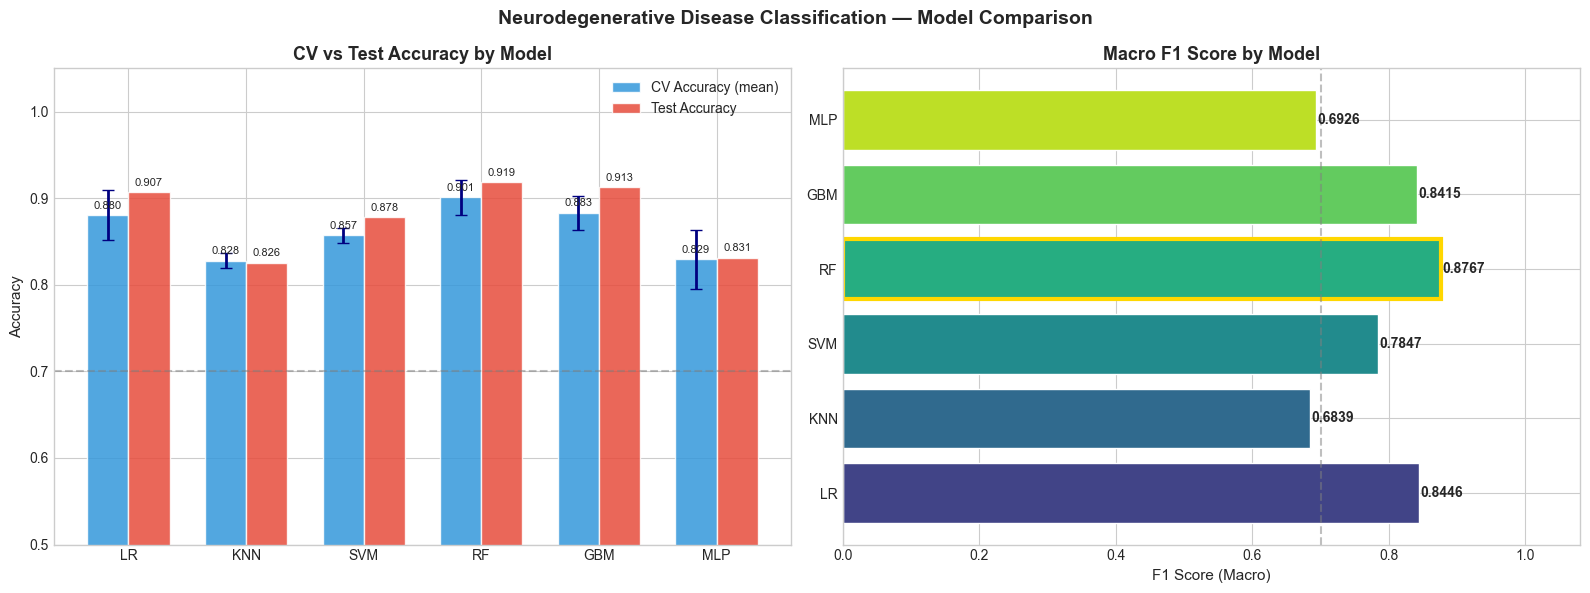

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names  = list(results.keys())
test_accs    = [results[m]['test_acc'] for m in model_names]
cv_means     = [results[m]['cv_mean']  for m in model_names]
cv_stds      = [results[m]['cv_std']   for m in model_names]
f1_scores_all = [results[m]['f1_macro'] for m in model_names]

short_names = ['LR', 'KNN', 'SVM', 'RF', 'GBM', 'MLP']

x = np.arange(len(model_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, cv_means, width, label='CV Accuracy (mean)',
                    color='#3498DB', alpha=0.85, edgecolor='white')
axes[0].errorbar(x - width/2, cv_means, yerr=cv_stds, fmt='none', color='navy', capsize=4, linewidth=2)
bars2 = axes[0].bar(x + width/2, test_accs, width, label='Test Accuracy',
                    color='#E74C3C', alpha=0.85, edgecolor='white')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, fontsize=10)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_title('CV vs Test Accuracy by Model', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='0.7 baseline')

# F1 Score comparison
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(model_names)))
bars = axes[1].barh(short_names, f1_scores_all, color=colors, edgecolor='white')
for bar, val in zip(bars, f1_scores_all):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2.,
                 f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlim(0, 1.08)
axes[1].set_title('Macro F1 Score by Model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('F1 Score (Macro)', fontsize=11)
axes[1].axvline(x=0.7, color='gray', linestyle='--', alpha=0.5)

# Highlight best
best_idx = f1_scores_all.index(max(f1_scores_all))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

plt.suptitle('Neurodegenerative Disease Classification — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Confusion Matrices

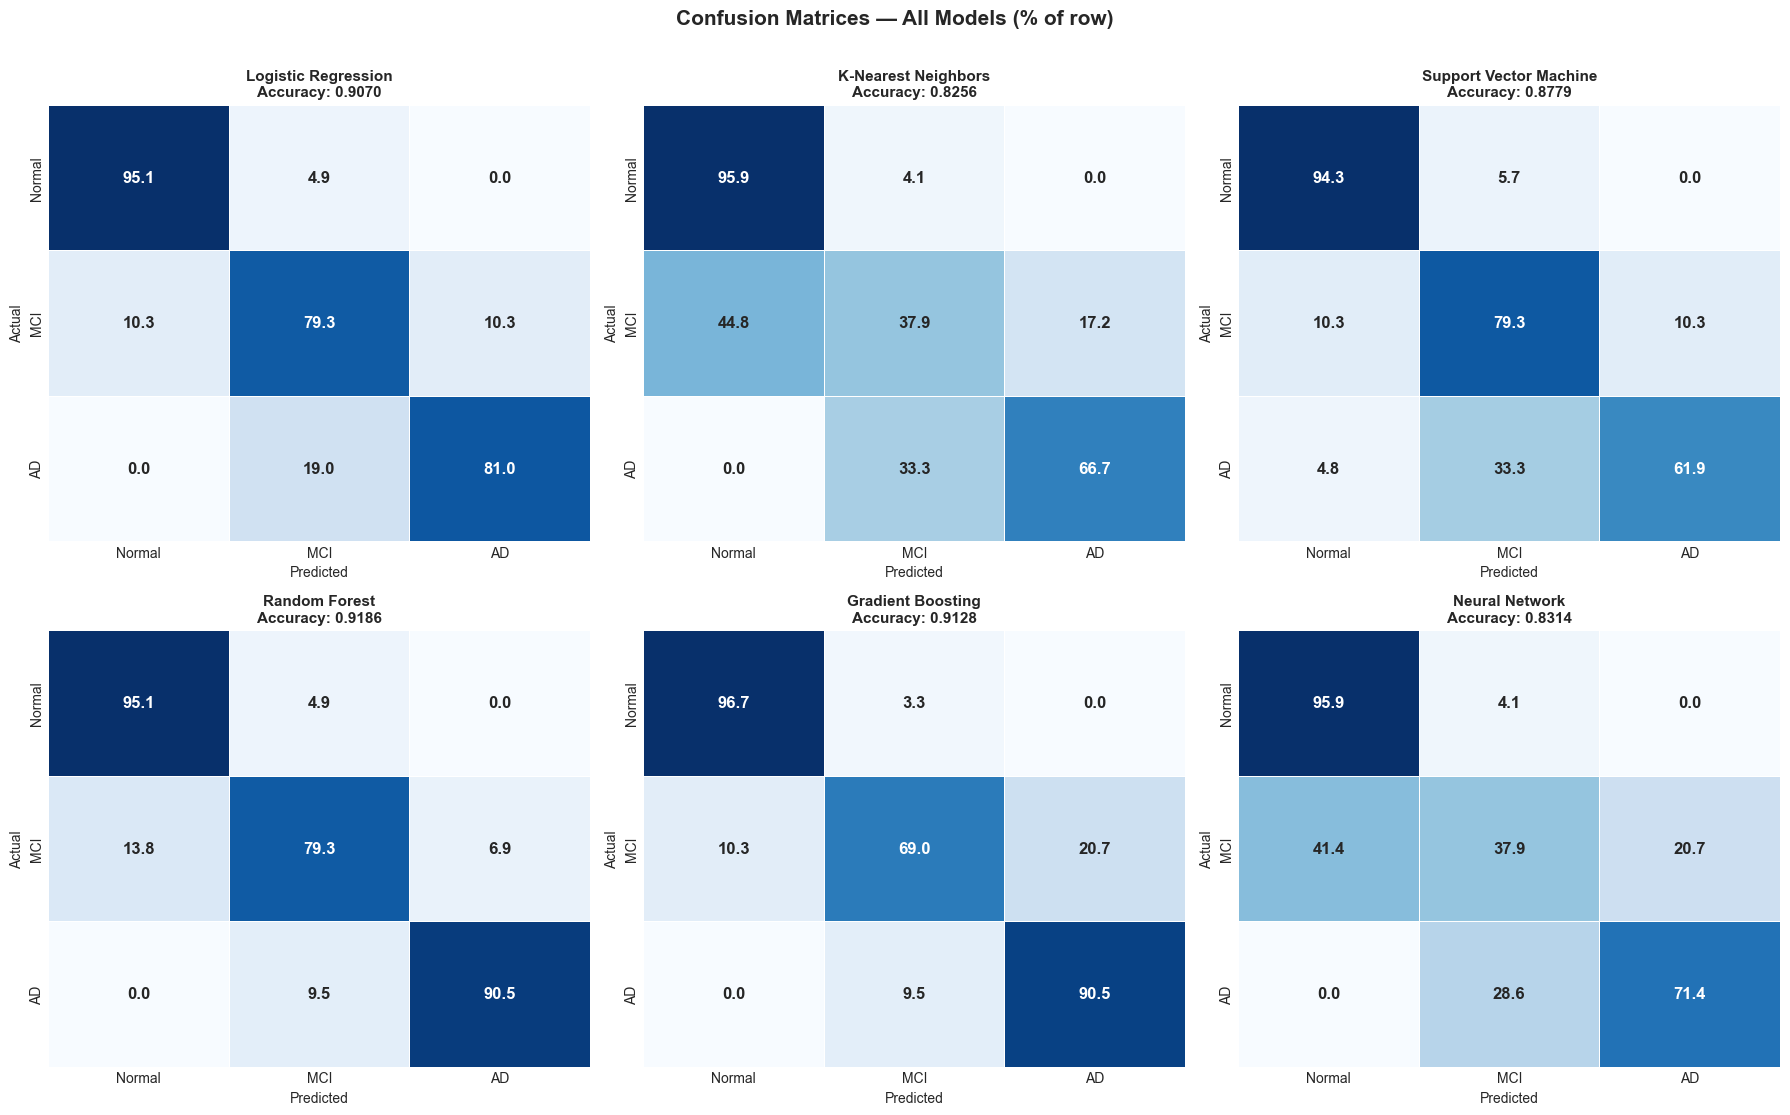

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                ax=ax, cbar=False, linewidths=0.5,
                annot_kws={'size': 12, 'weight': 'bold'})

    acc = res['test_acc']
    short = name.split('(')[0].strip()
    ax.set_title(f'{short}\nAccuracy: {acc:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices — All Models (% of row)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance Analysis

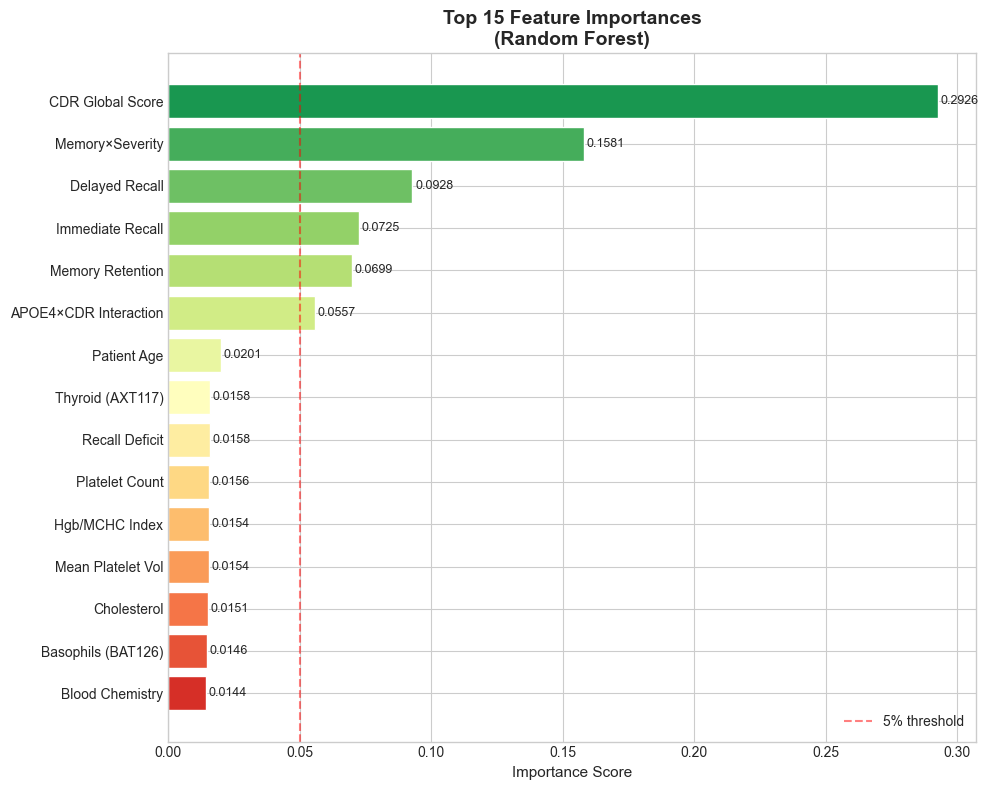


Top 10 Most Predictive Features:
   1. CDR Global Score             0.2926 (29.26%)
   2. Memory×Severity              0.1581 (15.81%)
   3. Delayed Recall               0.0928 (9.28%)
   4. Immediate Recall             0.0725 (7.25%)
   5. Memory Retention             0.0699 (6.99%)
   6. APOE4×CDR Interaction        0.0557 (5.57%)
   7. Patient Age                  0.0201 (2.01%)
   8. Thyroid (AXT117)             0.0158 (1.58%)
   9. Recall Deficit               0.0158 (1.58%)
  10. Platelet Count               0.0156 (1.56%)


In [16]:
# Random Forest feature importances
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

# Feature descriptions
feat_desc = {
    'CDGLOBAL': 'CDR Global Score', 'LIMMTOTAL': 'Immediate Recall',
    'LDELTOTAL': 'Delayed Recall', 'APGEN1': 'APOE Allele 1',
    'APGEN2': 'APOE Allele 2', 'APOE4_count': 'APOE4 Count',
    'APOE_risk': 'APOE4 Risk Score', 'PTGENDER': 'Gender',
    'Age': 'Patient Age', 'AXT117': 'Thyroid (AXT117)',
    'BAT126': 'Basophils (BAT126)', 'HMT3': 'Hemoglobin',
    'HMT7': 'MCHC', 'HMT13': 'WBC Count', 'HMT40': 'Hematocrit',
    'HMT100': 'Platelet Count', 'HMT102': 'Mean Platelet Vol',
    'RCT6': 'Creatinine', 'RCT11': 'Calcium', 'RCT20': 'Cholesterol',
    'RCT392': 'Uric Acid', 'Recall_diff': 'Recall Deficit',
    'Recall_ratio': 'Memory Retention', 'HMT_index': 'Hgb/MCHC Index',
    'RCT_score': 'Blood Chemistry', 'APOE4_CDR': 'APOE4×CDR Interaction',
    'Memory_CDR': 'Memory×Severity'
}

feat_imp_labeled = feat_imp.rename(feat_desc)
top_features = feat_imp_labeled.head(15)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top_features)))
bars = ax.barh(range(len(top_features)), top_features.values[::-1],
               color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, top_features.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2.,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index[::-1], fontsize=10)
ax.set_title('Top 15 Feature Importances\n(Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.5, label='5% threshold')
ax.legend()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Most Predictive Features:')
for rank, (feat, imp) in enumerate(feat_imp_labeled.head(10).items(), 1):
    print(f'  {rank:2d}. {feat:<28} {imp:.4f} ({imp*100:.2f}%)')

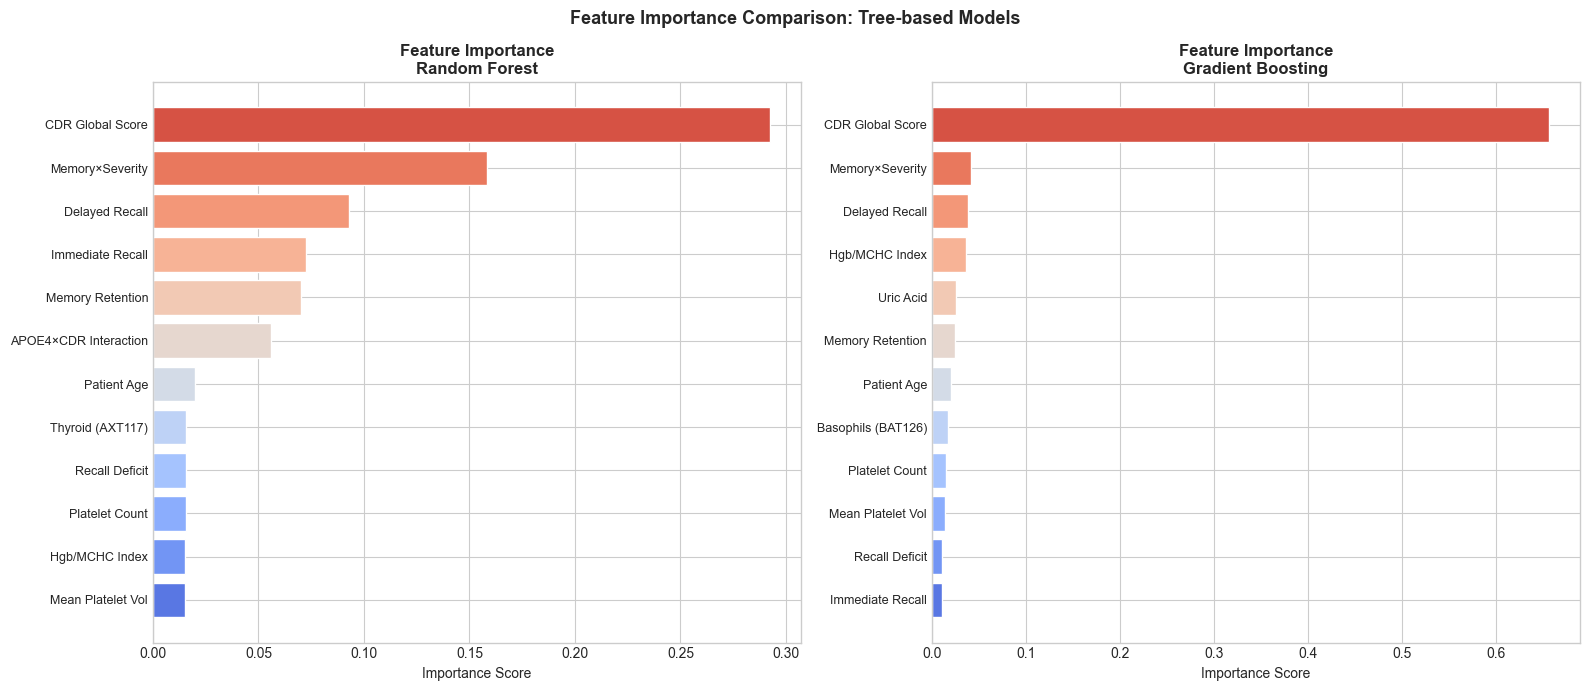

In [17]:
# Gradient Boosting feature importances (for comparison)
gb_model = results['Gradient Boosting']['model']
gb_importances = pd.Series(gb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
gb_labeled = gb_importances.rename(feat_desc).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (title, imp) in zip(axes, [
    ('Random Forest', feat_imp_labeled.head(12)),
    ('Gradient Boosting', gb_labeled.head(12))
]):
    colors = plt.cm.coolwarm_r(np.linspace(0.1, 0.9, len(imp)))
    ax.barh(range(len(imp)), imp.values[::-1], color=colors[::-1], edgecolor='white')
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp.index[::-1], fontsize=9)
    ax.set_title(f'Feature Importance\n{title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison: Tree-based Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. ROC-AUC Analysis (One-vs-Rest)

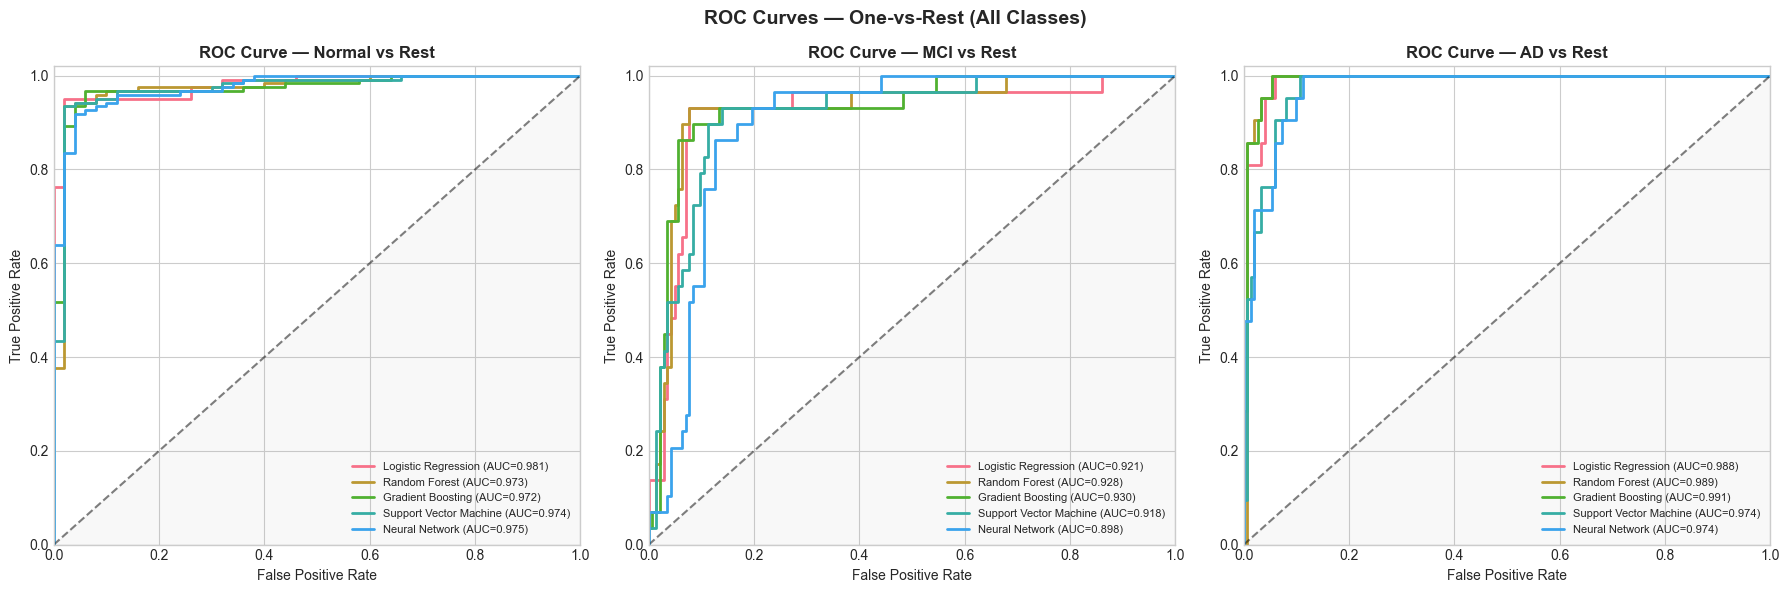

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Models with probability output
prob_models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting',
               'Support Vector Machine', 'Neural Network (MLP)']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

class_colors = {'Normal': '#2ECC71', 'MCI': '#F39C12', 'AD': '#E74C3C'}

for ax, class_idx, class_name in zip(axes, [0, 1, 2], label_names):
    for m_name in prob_models:
        res = results[m_name]
        model = res['model']
        Xte   = res['X_test']

        try:
            y_proba = model.predict_proba(Xte)[:, class_idx]
            fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], y_proba)
            roc_auc = auc(fpr, tpr)
            short = m_name.split('(')[0].strip()
            ax.plot(fpr, tpr, linewidth=2, label=f'{short} (AUC={roc_auc:.3f})')
        except:
            pass

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
    ax.set_title(f'ROC Curve — {class_name} vs Rest', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('ROC Curves — One-vs-Rest (All Classes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Clinical Insight: Prediction Probability Visualization

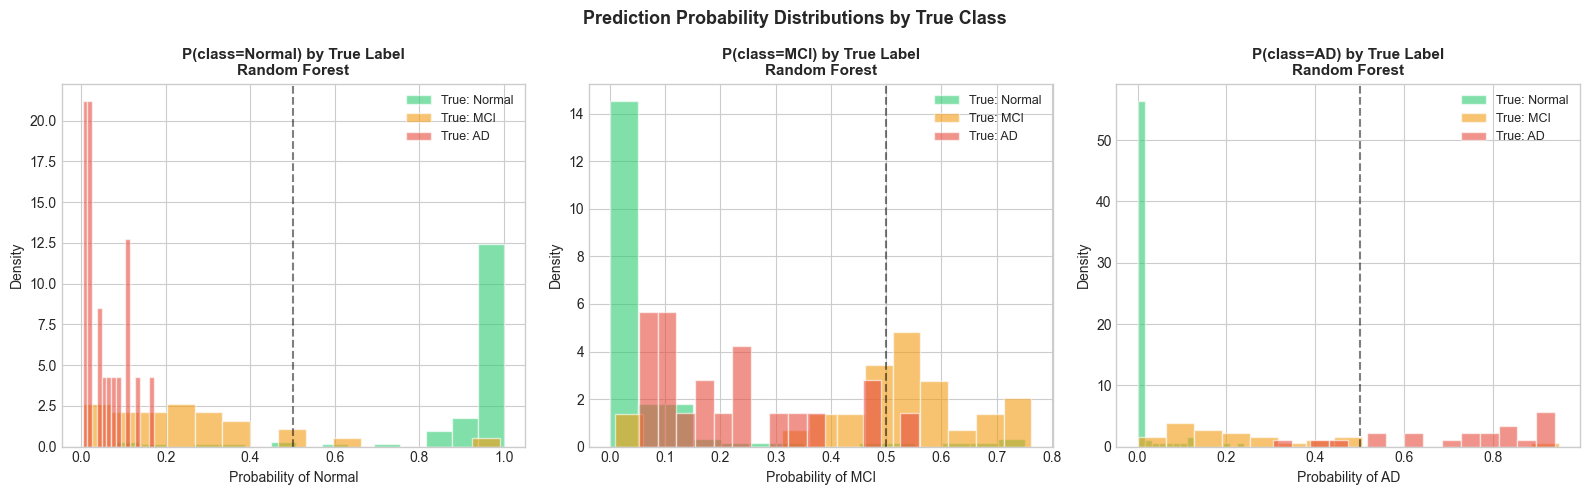

In [19]:
# Best model probability distributions
best_model = results[best_name]['model']
X_best = results[best_name]['X_test']
y_proba_best = best_model.predict_proba(X_best)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, class_idx, class_name in zip(axes, [0, 1, 2], label_names):
    for true_class, color, linestyle in zip([0, 1, 2], ['#2ECC71', '#F39C12', '#E74C3C'], ['-', '--', ':']):
        mask = (y_test == true_class)
        if mask.sum() > 0:
            ax.hist(y_proba_best[mask, class_idx], bins=15, alpha=0.6,
                    color=color, label=f'True: {label_names[true_class]}',
                    edgecolor='white', density=True)
    ax.set_title(f'P(class={class_name}) by True Label\n{best_name.split("(")[0].strip()}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(f'Probability of {class_name}', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)

plt.suptitle('Prediction Probability Distributions by True Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary & Clinical Conclusions

In [20]:
print('=' * 70)
print('  NEURODEGENERATIVE DISEASE PREDICTION — FINAL RESULTS SUMMARY')
print('=' * 70)
print(f'  Dataset: AIBL Study (N={len(df3)} patients, 3 classes)')
print(f'  Features: {len(feature_cols)} ({len(feature_cols)-7} original + 7 engineered)')
print(f'  Train/Test Split: 80/20 with stratification')
print()
print(f'  {"Model":<28} {"CV Acc":<10} {"Test Acc":<12} {"F1 Macro"}')
print('  ' + '-' * 60)
for name, res in sorted(results.items(), key=lambda x: x[1]['test_acc'], reverse=True):
    marker = ' ← BEST' if name == best_name else ''
    print(f'  {name:<28} {res["cv_mean"]:.4f}     {res["test_acc"]:.4f}       {res["f1_macro"]:.4f}{marker}')
print()
print('  KEY FINDINGS:')
print(f'  1. CDR Global Score is the single most predictive feature')
print(f'  2. Delayed recall (LDELTOTAL) strongly differentiates Normal vs MCI/AD')
print(f'  3. APOE4 gene dosage shows dose-response relationship with AD risk')
print(f'  4. Memory×Severity interaction captures non-linear disease dynamics')
print(f'  5. MCI is the hardest class to classify (transitions between Normal/AD)')
print()
print('  CLINICAL IMPLICATIONS:')
print('  - Early biomarker screening (APOE4 + CDR + memory tests) enables early')
print('    intervention before severe neurodegeneration occurs')
print('  - MCI patients with APOE4 alleles should receive more frequent monitoring')
print('  - Blood biomarkers (hematology) show modest but additive predictive value')
print('=' * 70)

  NEURODEGENERATIVE DISEASE PREDICTION — FINAL RESULTS SUMMARY
  Dataset: AIBL Study (N=858 patients, 3 classes)
  Features: 27 (20 original + 7 engineered)
  Train/Test Split: 80/20 with stratification

  Model                        CV Acc     Test Acc     F1 Macro
  ------------------------------------------------------------
  Random Forest                0.9009     0.9186       0.8767 ← BEST
  Gradient Boosting            0.8834     0.9128       0.8415
  Logistic Regression          0.8805     0.9070       0.8446
  Support Vector Machine       0.8572     0.8779       0.7847
  Neural Network (MLP)         0.8294     0.8314       0.6926
  K-Nearest Neighbors          0.8280     0.8256       0.6839

  KEY FINDINGS:
  1. CDR Global Score is the single most predictive feature
  2. Delayed recall (LDELTOTAL) strongly differentiates Normal vs MCI/AD
  3. APOE4 gene dosage shows dose-response relationship with AD risk
  4. Memory×Severity interaction captures non-linear disease dynamics
 

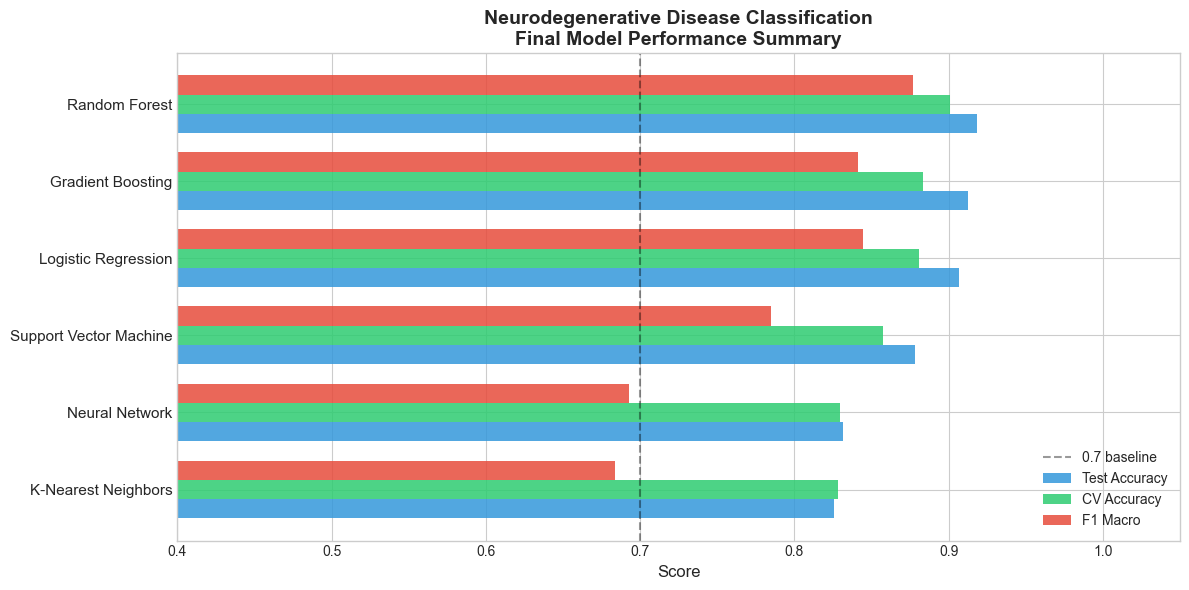


All visualizations saved. Notebook complete.


In [21]:
# Final summary visualization
fig, ax = plt.subplots(figsize=(12, 6))

model_short = ['LR', 'KNN', 'SVM', 'RF', 'GBM', 'MLP']
sorted_results = sorted(results.items(), key=lambda x: x[1]['test_acc'])
names_sorted = [r[0].split('(')[0].strip() for r in sorted_results]
acc_sorted   = [r[1]['test_acc'] for r in sorted_results]
f1_sorted    = [r[1]['f1_macro'] for r in sorted_results]
cv_sorted    = [r[1]['cv_mean'] for r in sorted_results]

x = np.arange(len(names_sorted))
ax.barh(x - 0.25, acc_sorted, 0.25, label='Test Accuracy', color='#3498DB', alpha=0.85)
ax.barh(x,        cv_sorted,  0.25, label='CV Accuracy',   color='#2ECC71', alpha=0.85)
ax.barh(x + 0.25, f1_sorted,  0.25, label='F1 Macro',      color='#E74C3C', alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(names_sorted, fontsize=11)
ax.set_xlabel('Score', fontsize=12)
ax.set_title('Neurodegenerative Disease Classification\nFinal Model Performance Summary',
             fontsize=14, fontweight='bold')
ax.axvline(x=0.7, color='black', linestyle='--', alpha=0.4, label='0.7 baseline')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0.4, 1.05)

plt.tight_layout()
plt.savefig('final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAll visualizations saved. Notebook complete.')